# US equities panel: how much friction the strategy can absorb

Three notebooks have now built strategies on this panel and measured them without charging
anything to trade: [`16_backtest`](16_backtest.ipynb) took each model's predictions and held the
top names against the bottom ones at equal weight, [`17_portfolio_management`](17_portfolio_management.ipynb)
varied how the money is spread across those names, and
[`18_risk_management`](18_risk_management.ipynb) laid stops and exits over the result. This
notebook takes what those produced and asks the question none of them could: at what level of
trading cost does it stop being worth doing?

**This is a sensitivity analysis, not another round of selection.** One configuration per label
is fixed first - the highest validation Sharpe among the strategies the three earlier stages
produced - and then every declared cost value is applied to that same fixed strategy. Nothing
here may replace the configuration that was chosen; a cost sweep that reordered the field would
be choosing a strategy on the cost assumption rather than measuring one against it.

**Two ways of charging for a trade, because they are not the same claim.** A cost in **basis
points** is a fraction of the value traded, so a hundred dollars of a five-dollar stock and a
hundred dollars of a five-hundred-dollar stock cost the same. A cost **per share** is a fixed
amount on each share, so the cheap stock costs a hundred times more to trade. On a panel that
spans both, those two assumptions disagree most exactly where this strategy holds most of its
names, which is why both grids are swept and reported side by side rather than one being picked.

**On this panel the per-share regime is exploratory and the basis-point regime is the headline.**
The reason is in the prices: the universe runs from a five-dollar floor to several hundred
dollars, and the price a historical bar carries has been adjusted for splits and dividends, so a
fixed per-share charge applied to an adjusted price is not the charge that would have been paid.
`config/setup.yaml` records that division.

**Learning objectives.** By the end of this notebook you will be able to:

- Say why a cost sweep has to fix its strategy before it varies anything, and what a sweep that
  reordered the field would actually be selecting on.
- Derive which stages a re-priced strategy may be drawn from, rather than listing them, and say
  what a listed set of stages silently drops.
- State the difference between a proportional and a per-share cost, and identify the kind of
  universe on which the two disagree most.
- Read a curve of net performance against cost level and say what the level where it crosses
  zero does and does not tell you about tradability.

**Book reference**: Chapter 18, Sections 18.2-18.5

**Prerequisites**: [`16_backtest`](16_backtest.ipynb),
[`17_portfolio_management`](17_portfolio_management.ipynb) and
[`18_risk_management`](18_risk_management.ipynb) publish the three stages of strategy this
notebook re-prices.

In [1]:
"""Generate the US-equities cost-sensitivity validation population."""

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from case_studies.research import (
    CandidateSet,
    OfficialPopulation,
    candidate_set_supersedes,
    open_study,
    plan_backtests,
    population_supersedes,
    run_backtests,
)
from case_studies.research.strategy import strategy_warmup_periods
from case_studies.utils.backtest_loaders import load_backtest_prices_for
from case_studies.utils.sweep_config import (
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import STAGE_SEQUENCE
from utils.style import add_message_title, ml4t_palette, show_with_alt, zero_line

In [2]:
CASE_STUDY_ID = "us_equities_panel"
BASELINE_SET_NAMES = [
    "us-equities-fwd-ret-1d-baseline-v1",
]
ALLOCATION_SET_NAMES = [
    "us-equities-fwd-ret-1d-allocation-v1",
]
RISK_SET_NAMES = [
    "us-equities-fwd-ret-1d-risk-overlay-v1",
]
EXECUTION_TIER = "canonical"
POPULATION_NAME = ""
SUPERSEDES_POPULATION = ""
SUPERSEDES_SETS: dict = {}
# Empty means this run writes to the case study's own store, which is what canonical
# production execution wants. Any other value routes the run's writes there instead, at
# either tier, and is how a rehearsal at full scale is compared against the published
# result without being able to damage it.
WORKSPACE = ""
PREVIEW_LABELS = []
PREVIEW_MAX_SOURCE_ROWS = 0
PREVIEW_MAX_COST_VALUES = 0
MAX_SYMBOLS = 0

## 1. Which strategies get re-priced

A cost sweep takes a strategy that has already been chosen and asks what it is worth at a range
of trading costs. So the pool it draws from is every stage that can produce the configuration a
reader would carry forward - and that pool is derived here rather than listed, because a listed
one goes stale the moment a stage is added.

`STAGE_SEQUENCE` is the order the backtest stages run in: signal, allocation, risk overlay, then
cost sensitivity. Everything before the last one is a stage a strategy can come from, so the pool
is the sequence minus the terminal stage.

**A stage left out of that pool does not raise.** A risk overlay shares its allocation parent's
prediction hash, so a pool missing `risk_overlay` still resolves a source for every label - the
un-overlaid one - and the cost curve it draws is then a curve for a different strategy from the
one it is named after. Deriving the pool is what makes a stage added later reach it without
anyone remembering to come here.

Both tiers resolve the study through `open_study`. It reads the labels, features and earlier
results in place and redirects only writes, so a preview run sweeps the same inputs a canonical
one does and cannot publish over it.

In [4]:
PRE_COST_STAGES = tuple(stage for stage in STAGE_SEQUENCE if stage != "cost_sensitivity")

declared_set_names = [*BASELINE_SET_NAMES, *ALLOCATION_SET_NAMES, *RISK_SET_NAMES]
workspace_override = os.environ.get("ML4T_OUTPUT_DIR") or WORKSPACE
if EXECUTION_TIER == "canonical":
    if PREVIEW_LABELS or PREVIEW_MAX_SOURCE_ROWS or PREVIEW_MAX_COST_VALUES or MAX_SYMBOLS:
        raise ValueError("Canonical execution cannot declare preview reductions")
    if not declared_set_names or len(declared_set_names) != len(set(declared_set_names)):
        raise ValueError("Canonical execution requires unique named strategy sets")
    study = open_study(
        CASE_STUDY_ID,
        execution_tier=EXECUTION_TIER,
        workspace=Path(workspace_override) if workspace_override else None,
    )
elif EXECUTION_TIER == "preview":
    if (
        not PREVIEW_LABELS
        or PREVIEW_MAX_SOURCE_ROWS < 1
        or PREVIEW_MAX_COST_VALUES < 1
        or MAX_SYMBOLS < 1
    ):
        raise ValueError(
            "Preview execution requires labels and explicit row, cost, and symbol limits"
        )
    study = open_study(
        CASE_STUDY_ID,
        execution_tier=EXECUTION_TIER,
        workspace=Path(workspace_override or "experiments"),
    )
else:
    raise ValueError(f"Unsupported execution tier: {EXECUTION_TIER!r}")

## 2. The rows this run will sweep

A canonical run takes the frozen sets by name. A preview run takes the highest-Sharpe rows of
the declared labels up to its declared limit, which is what makes a reduced proof cheap without
letting it publish anything.

In [5]:
backtest_catalog = study.backtests.table(include_preview=True)
if EXECUTION_TIER == "canonical":
    declared_sets = tuple(CandidateSet.one(study, name=name) for name in declared_set_names)
    if any(result_set.member_kind != "backtest" for result_set in declared_sets):
        raise ValueError("Every declared input set must contain backtests")
    source_members = tuple(member for result_set in declared_sets for member in result_set.members)
    if len(source_members) != len(set(source_members)):
        raise ValueError("Declared baseline and allocation sets overlap")
    eligible = backtest_catalog.filter(pl.col("backtest_hash").is_in(source_members))
    if eligible.height != len(source_members):
        raise ValueError("The backtest catalog does not contain every declared strategy member")
else:
    eligible = (
        backtest_catalog.filter(
            (pl.col("execution_tier") == "preview")
            & pl.col("stage").is_in(PRE_COST_STAGES)
            & pl.col("label").is_in(PREVIEW_LABELS)
        )
        .sort("sharpe", "backtest_hash", descending=[True, False])
        .head(PREVIEW_MAX_SOURCE_ROWS)
    )

ineligible = eligible.filter(
    (pl.col("split") != "validation")
    | (pl.col("execution_tier") != EXECUTION_TIER)
    | ~pl.col("stage").is_in(PRE_COST_STAGES)
    | ~pl.col("complete")
    | pl.col("sharpe").is_null()
    | ~pl.col("sharpe").is_finite()
)
if eligible.is_empty() or not ineligible.is_empty():
    raise ValueError("Cost analysis requires complete finite selection-eligible validation rows")

## 3. Fixing the strategy that will be re-priced

One configuration per label, taken by validation Sharpe from the pool above. `setup.yaml`
declares how many to keep - `cost_sensitivity: 1` - and that number is the whole design of this
section: a sweep over several strategies at several costs produces a table in which a reader
cannot tell a cost effect from a strategy difference.

Everything that identifies the strategy is now held: which model produced the predictions, which
checkpoint of it, how the signal turned those predictions into positions, how the money was
spread across them, and any overlay laid on top. Only the cost varies from here.

**"Any overlay laid on top" is the part that has to be carried deliberately.** A strategy drawn
from the signal or allocation stage has no overlay, and the backtest runner treats an absent
overlay as none - so a risk-overlay strategy re-priced without its risk block runs clean and
produces a cost curve for the un-overlaid strategy under the overlaid one's name. That is the
same failure as leaving `risk_overlay` out of the pool, reached from the other side. Section 4
carries the block through and refuses a risk-overlay source whose spec does not hold one.

**Because one configuration is kept per label, some summaries have no width.** A median, a range
or a confidence band across configurations is computed over a single row, so all three coincide.
That is a property of the shortlist size rather than a finding about stability.


**Prices are cached per label and per warmup, not once per label.** A strategy records the digest
of exactly the price frame it was handed, and allocators need different amounts of history before
their first decision: none for the simple weighting methods, a volatility window for
inverse-volatility and risk parity, a longer lookback for the mean-variance ones. A single frame
long enough for the greediest of them would record a digest that nothing recomputing at a
member's own warmup can reproduce, and the later notebooks and the holdout evaluation both check
exactly that.

In [6]:
_price_cache: dict[tuple[str, int], object] = {}


def prices_for(label, warmup_periods):
    key = (str(label), int(warmup_periods))
    if key not in _price_cache:
        _price_cache[key] = load_backtest_prices_for(
            CASE_STUDY_ID,
            label,
            split="validation",
            max_symbols=MAX_SYMBOLS,
            warmup_periods=int(warmup_periods),
        )
    return _price_cache[key]


top_n = get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
selected_parts = []
for label in eligible.get_column("label").unique().sort().to_list():
    selected_parts.append(
        eligible.filter(pl.col("label") == label)
        .sort("sharpe", "backtest_hash", descending=[True, False])
        .head(top_n)
    )
selected_sources = pl.concat(selected_parts).sort("label", "backtest_hash")
if selected_sources.is_empty():
    raise RuntimeError("No cost-sensitivity source configuration was selected")

selected_sources.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "stage",
    "prediction_hash",
    "backtest_hash",
    "sharpe",
)

label,family,config_name,checkpoint_kind,checkpoint_value,stage,prediction_hash,backtest_hash,sharpe
str,str,str,str,i64,str,str,str,f64
"""fwd_ret_1d""","""gbm""","""leaves_63_mse""","""iteration""",500,"""signal""","""a1c1ea483209""","""3076efd14f7c""",1.052785


## 4. The two cost grids

**The basis-point grid** charges a fraction of the value traded and splits it evenly between two
things a trade pays for: the commission, and the slippage from crossing the spread. Splitting it
evenly is a declaration rather than a measurement; what the sweep varies is the total.

**The per-share grid** charges the configured commission per share plus a uniform half-spread in
cents. A **half-spread** is what one side of a round trip pays to cross the quoted bid-ask gap,
so a round trip pays it twice.

Every identity is written down before the first backtest runs, for the same reason the model
populations were: a sweep that came out short would otherwise look like a smaller sweep rather
than a failed one.

`SUPERSEDES_POPULATION` and `SUPERSEDES_SETS` name the generation this run replaces. A population
and a candidate set are both immutable, so a re-run that admits different members has to say
which snapshot it supersedes or the registry refuses the write. Both default to empty, which is
right for a first run and for a reader's clean clone; `population_supersedes` and
`candidate_set_supersedes` withhold a declared hash wherever offering it would be refused.

In [7]:
bps_values = get_cost_grid_bps(CASE_STUDY_ID)
half_spread_values = get_cost_grid_half_spread_usd(CASE_STUDY_ID)
if EXECUTION_TIER == "preview":
    bps_values = bps_values[:PREVIEW_MAX_COST_VALUES]
    half_spread_values = half_spread_values[:PREVIEW_MAX_COST_VALUES]
if not bps_values or not half_spread_values:
    raise ValueError("Both configured cost regimes require at least one value")

per_share_commission = get_per_share_commission(CASE_STUDY_ID)

In [8]:
cost_requests = [
    {
        "regime": "bps",
        "cost_value": total_bps,
        "costs": {
            "model": "percentage",
            "commission_bps": total_bps / 2,
            "slippage_bps": total_bps / 2,
        },
    }
    for total_bps in bps_values
]
cost_requests.extend(
    {
        "regime": "per_share",
        "cost_value": half_spread,
        "costs": {
            "model": "per_share_plus_spread",
            "per_share": per_share_commission,
            "minimum": 0.0,
            "default_half_spread_usd": half_spread,
            "spread_convention": "half_spread",
        },
    }
    for half_spread in half_spread_values
)

prediction_catalog = study.predictions.table(include_preview=True)
planned_requests = []
plan_rows = []

In [9]:
def cost_member_records(
    label, source_row, selection, signal, allocation, risk, cost_request, expected_hash
):
    request = {
        "label": label,
        "selection": selection,
        "signal": signal,
        "allocation": allocation,
        "risk": risk,
        "costs": cost_request["costs"],
        "regime": cost_request["regime"],
        "cost_value": cost_request["cost_value"],
        "prediction_hash": source_row["prediction_hash"],
        "source_backtest_hash": source_row["backtest_hash"],
        "expected_hash": expected_hash,
    }
    row = {
        "label": label,
        "source_stage": source_row["stage"],
        "source_backtest_hash": source_row["backtest_hash"],
        "regime": cost_request["regime"],
        "cost_value": cost_request["cost_value"],
        "prediction_hash": source_row["prediction_hash"],
        "backtest_hash": expected_hash,
    }
    return request, row

In [10]:
def plan_cost_member(label, prices, cost_request, source_row):
    selected_prediction = prediction_catalog.filter(
        pl.col("prediction_hash") == source_row["prediction_hash"]
    )
    if selected_prediction.height != 1:
        raise ValueError("A cost source must resolve one prediction catalog row")
    source_spec = json.loads(source_row["spec_json"])
    signal = dict(source_spec["strategy"]["signal"])
    allocation = source_spec["strategy"].get("allocation")
    # A risk block is absent from a signal- or allocation-stage source and defaults to None in
    # both planners, so a re-priced overlay could silently lose it. Asserted below.
    risk = source_spec["strategy"].get("risk")
    if source_row["stage"] == "risk_overlay" and not risk:
        raise ValueError(
            f"backtest {source_row['backtest_hash']} is staged risk_overlay and its spec carries "
            "no risk block, so re-pricing it would drop the overlay it is named for"
        )
    plan = plan_backtests(
        study,
        predictions=selected_prediction,
        signal=signal,
        allocation=allocation,
        risk=risk,
        costs=cost_request["costs"],
        prices=prices,
        chapter="ch18",
    )
    if len(plan.members) != 1:
        raise RuntimeError("One cost request must plan one backtest")
    return cost_member_records(
        label,
        source_row,
        selected_prediction,
        signal,
        allocation,
        risk,
        cost_request,
        plan.expected_hashes[0],
    )

In [11]:
for label in selected_sources.get_column("label").unique().sort().to_list():
    for source_row in selected_sources.filter(pl.col("label") == label).iter_rows(named=True):
        for cost_request in cost_requests:
            prices = prices_for(
                label,
                # The source's allocation lives in its spec_json, not as a catalog column, so
                # source_row.get("allocation") is always None and would silently warm up 0 bars
                # for every allocation-stage source.
                strategy_warmup_periods(json.loads(source_row["spec_json"])),
            )
            request, row = plan_cost_member(label, prices, cost_request, source_row)
            planned_requests.append(request)
            plan_rows.append(row)

In [12]:
planned_population = pl.DataFrame(plan_rows).sort(
    "label", "regime", "cost_value", "source_backtest_hash", "backtest_hash"
)
if planned_population.get_column("backtest_hash").n_unique() != planned_population.height:
    raise ValueError("The cost plan contains duplicate backtest identities")

official_population = None
if EXECUTION_TIER == "canonical":
    population_name = POPULATION_NAME or "us-equities-cost-sensitivity-v1"
    official_population = OfficialPopulation.create(
        study,
        name=population_name,
        supersedes=population_supersedes(
            study, name=population_name, declared=SUPERSEDES_POPULATION
        ),
        member_kind="backtest",
        members=tuple(planned_population.get_column("backtest_hash")),
    )

planned_population

label,source_stage,source_backtest_hash,regime,cost_value,prediction_hash,backtest_hash
str,str,str,str,f64,str,str
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""bps""",0.0,"""a1c1ea483209""","""4b44e0bf2e42"""
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""bps""",1.0,"""a1c1ea483209""","""077ecbed634b"""
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""bps""",2.0,"""a1c1ea483209""","""f5aab0bcbaa7"""
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""bps""",3.0,"""a1c1ea483209""","""e5dc530698c8"""
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""bps""",5.0,"""a1c1ea483209""","""3074789e0326"""
…,…,…,…,…,…,…
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""per_share""",0.005,"""a1c1ea483209""","""5d35ff98a5de"""
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""per_share""",0.01,"""a1c1ea483209""","""1b77dc32509c"""
"""fwd_ret_1d""","""signal""","""3076efd14f7c""","""per_share""",0.025,"""a1c1ea483209""","""aaf286e981d9"""


## 5. Running the sweep

Each cost value becomes its own backtest of the same fixed strategy. They are independent, so a
failure costs that one point on the curve and leaves the rest reusable, and the declared
membership stays intact for a re-run to fill.

In [13]:
execution_rows = []
failure_rows = []


def execute_cost_member(prices, request):
    execution = run_backtests(
        study,
        predictions=request["selection"],
        signal=request["signal"],
        allocation=request["allocation"],
        risk=request["risk"],
        costs=request["costs"],
        prices=prices,
        chapter="ch18",
    )
    if len(execution.results) != 1 or execution.results[0].hash != request["expected_hash"]:
        raise RuntimeError("Cost execution changed its planned identity")
    return {
        "label": request["label"],
        "source_backtest_hash": request["source_backtest_hash"],
        "regime": request["regime"],
        "cost_value": request["cost_value"],
        "backtest_hash": execution.results[0].hash,
        "status": execution.diagnostics[0]["status"],
    }

In [14]:
for label in selected_sources.get_column("label").unique().sort().to_list():
    for request in (item for item in planned_requests if item["label"] == label):
        try:
            prices = prices_for(
                label,
                strategy_warmup_periods({"strategy": {"allocation": request["allocation"]}}),
            )
            execution_rows.append(execute_cost_member(prices, request))
        except Exception as error:
            failure_rows.append(
                {
                    "label": label,
                    "source_backtest_hash": request["source_backtest_hash"],
                    "regime": request["regime"],
                    "cost_value": request["cost_value"],
                    "backtest_hash": request["expected_hash"],
                    "error_type": type(error).__name__,
                    "error": str(error),
                }
            )

In [15]:
execution_diagnostics = pl.DataFrame(
    execution_rows,
    schema={
        "label": pl.String,
        "source_backtest_hash": pl.String,
        "regime": pl.String,
        "cost_value": pl.Float64,
        "backtest_hash": pl.String,
        "status": pl.String,
    },
)
failures = pl.DataFrame(
    failure_rows,
    schema={
        "label": pl.String,
        "source_backtest_hash": pl.String,
        "regime": pl.String,
        "cost_value": pl.Float64,
        "backtest_hash": pl.String,
        "error_type": pl.String,
        "error": pl.String,
    },
)
if not failures.is_empty():
    raise RuntimeError(f"Cost population has {failures.height} unsuccessful members")

if official_population is not None:
    official_population.require_complete()

execution_diagnostics

label,source_backtest_hash,regime,cost_value,backtest_hash,status
str,str,str,f64,str,str
"""fwd_ret_1d""","""3076efd14f7c""","""bps""",0.0,"""4b44e0bf2e42""","""reused"""
"""fwd_ret_1d""","""3076efd14f7c""","""bps""",1.0,"""077ecbed634b""","""reused"""
"""fwd_ret_1d""","""3076efd14f7c""","""bps""",2.0,"""f5aab0bcbaa7""","""reused"""
"""fwd_ret_1d""","""3076efd14f7c""","""bps""",3.0,"""e5dc530698c8""","""reused"""
"""fwd_ret_1d""","""3076efd14f7c""","""bps""",5.0,"""3074789e0326""","""reused"""
…,…,…,…,…,…
"""fwd_ret_1d""","""3076efd14f7c""","""per_share""",0.005,"""5d35ff98a5de""","""reused"""
"""fwd_ret_1d""","""3076efd14f7c""","""per_share""",0.01,"""1b77dc32509c""","""reused"""
"""fwd_ret_1d""","""3076efd14f7c""","""per_share""",0.025,"""aaf286e981d9""","""reused"""


## 6. Naming the curves

One set per label, holding both regimes, under a name
[`22_strategy_analysis`](22_strategy_analysis.ipynb) opens. These rows describe a strategy that
was already chosen, so they stay out of the pool anything selects from - a cost row winning a
selection would mean the cost assumption picked the strategy.

**The freeze is also the comparability check.** No comparison contract is declared, which makes
every field of the protocol required-constant: two members that disagree on their
cross-validation design measured their Sharpe on different folds, so ranking them is not a
comparison, and this is the only thing that checks it.

In [16]:
set_rows = []
completed = study.backtests.table(include_preview=True).filter(
    pl.col("backtest_hash").is_in(planned_population.get_column("backtest_hash"))
)
if (
    completed.height != planned_population.height
    or completed.filter(~pl.col("complete")).height
    or completed.filter(pl.col("stage") != "cost_sensitivity").height
    or completed.filter(pl.col("execution_tier") != EXECUTION_TIER).height
    or completed.filter(pl.col("sharpe").is_null() | ~pl.col("sharpe").is_finite()).height
):
    raise RuntimeError("The cost catalog is incomplete or mis-staged")
if EXECUTION_TIER == "canonical":
    for label in completed.get_column("label").unique().sort().to_list():
        label_name = label.replace("_", "-")
        result_set_name = f"us-equities-{label_name}-cost-sensitivity-v1"
        result_set = study.backtests.freeze(
            completed.filter(pl.col("label") == label),
            name=result_set_name,
            supersedes=candidate_set_supersedes(
                study, name=result_set_name, declared=SUPERSEDES_SETS.get(result_set_name, "")
            ),
        )
        set_rows.append(
            {"label": label, "set_name": result_set.name, "members": len(result_set.members)}
        )

compatible_sets = pl.DataFrame(
    set_rows,
    schema={"label": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

/tmp/ipykernel_2612911/3727152310.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  completed = study.backtests.table(include_preview=True).filter(


label,set_name,members
str,str,i64
"""fwd_ret_1d""","""us-equities-fwd-ret-1d-cost-se…",17


## 7. Reading the curves

One line per label per regime. Everything identifying the strategy is fixed along a line and
only the cost changes, so the slope is what friction does to this strategy and the crossing point
is the level at which it stops paying.

Read the two regimes as two assumptions rather than as two measurements of one thing. They order
the universe differently, and where they disagree most is the low-price end of the panel, where a
broad long-short book holds a large share of its names.

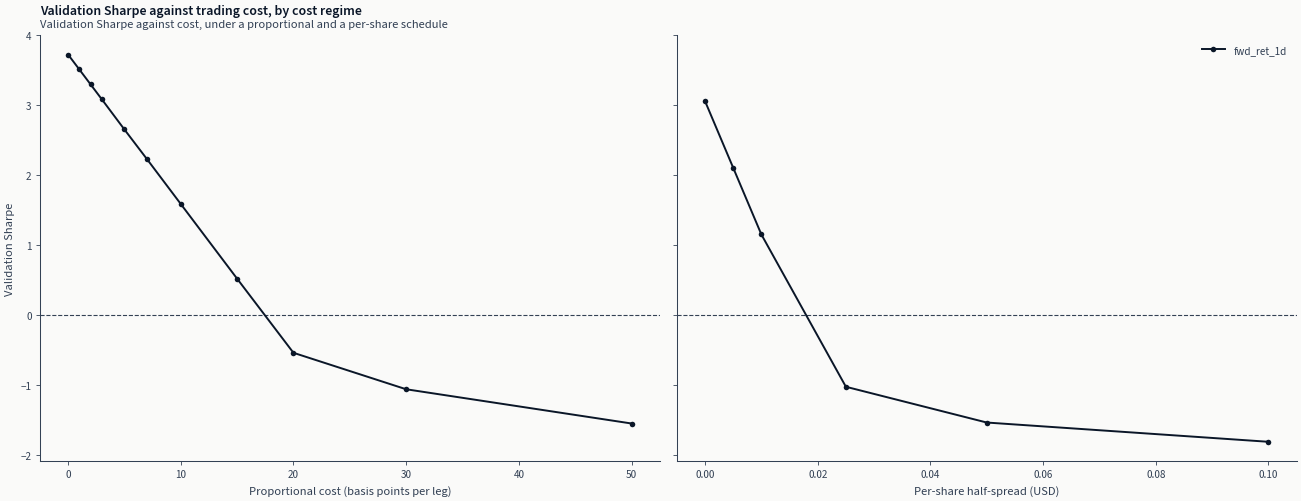

In [17]:
cost_results = planned_population.select("label", "regime", "cost_value", "backtest_hash").join(
    completed.select("backtest_hash", "sharpe"),
    on="backtest_hash",
    how="inner",
    validate="1:1",
)
if cost_results.height != planned_population.height:
    raise RuntimeError("The plotted cost population differs from the planned population")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
regime_labels = {
    "bps": "Proportional cost (basis points per leg)",
    "per_share": "Per-share half-spread (USD)",
}
curve_labels = cost_results.get_column("label").unique().sort().to_list()
# `ml4t_palette` returns a list of that many colours, so it is called once and indexed.
palette = ml4t_palette(len(curve_labels), categorical=True)
for ax, regime in zip(axes, ("bps", "per_share"), strict=True):
    regime_rows = cost_results.filter(pl.col("regime") == regime)
    for index, label in enumerate(curve_labels):
        curve = regime_rows.filter(pl.col("label") == label).sort("cost_value")
        ax.plot(
            curve["cost_value"],
            curve["sharpe"],
            marker="o",
            markersize=4,
            lw=1.4,
            color=palette[index],
            label=label,
        )
    zero_line(ax)
    ax.set_xlabel(regime_labels[regime])
axes[0].set_ylabel("Validation Sharpe")
axes[1].legend(fontsize=8, frameon=False)
add_message_title(
    axes[0],
    "Validation Sharpe against trading cost, by cost regime",
    subtitle="Validation Sharpe against cost, under a proportional and a per-share schedule",
)
# The alt text reads the crossing from the frame rather than asserting one: a curve described as
# crossing zero when it never does is a claim the data refutes, and where it crosses is the whole
# question this notebook asks.
_crossings = []
for regime in ("bps", "per_share"):
    for label in curve_labels:
        curve = (
            cost_results.filter((pl.col("regime") == regime) & (pl.col("label") == label))
            .sort("cost_value")
            .filter(pl.col("sharpe") <= 0)
        )
        if curve.height:
            _crossings.append((regime, label, curve.get_column("cost_value")[0]))
if _crossings:
    _crossing_text = "; ".join(
        f"{label} first reaches zero or below at {value:g} on the {regime} axis"
        for regime, label, value in _crossings
    )
else:
    _crossing_text = (
        "no curve reaches zero at any declared cost, so the sweep does not bracket a break-even"
    )
show_with_alt(
    fig,
    "Two line charts side by side sharing a vertical axis, one line per label with a dashed line "
    "at zero. The left panel plots validation Sharpe against a proportional cost in basis points "
    "per leg, the right against a per-share half-spread in dollars; both start at zero cost on "
    f"the left of their axis. Read from the underlying frame: {_crossing_text}.",
)

## What to notice

**A sweep has to fix its strategy before it varies anything.** Every row above is the same
model, the same checkpoint, the same names on the same dates, re-priced. If the sweep were
allowed to reorder the field, the strategy carried forward would be whichever one happened to
suit the cost assumption, which is choosing a strategy on an assumption rather than testing one
against it. That is why these rows are registered outside the population selection is made over.

**The two regimes are two assumptions, not two measurements of one thing.** A proportional cost
charges the same fraction whatever the share price; a per-share cost charges the same cents on a
five-dollar stock as on a five-hundred-dollar one. They disagree most on the cheap end of the
panel, which is where a broad long-short book holds a large share of its names, so an ordering
that holds under one is not thereby established under the other.

**Where a curve crosses zero is a break-even, and it does not say the strategy is tradable.**
It says what
uniform friction this strategy could absorb before the validation Sharpe went negative. Real
friction is not uniform: it varies by name, by size, by time of day, and it grows with the
position relative to what the stock trades. A strategy whose break-even sits far above any
plausible schedule has cleared a floor, not proved it can be traded.

**Known limitations.** One configuration per label is re-priced, so nothing here says how the
cost curve would look for a strategy that traded differently. The schedules are flat and applied
to every name equally, and on this panel the per-share regime is exploratory for the reason the
preamble gives - the prices are split- and dividend-adjusted, so a fixed charge per share is not
the charge that would have been paid. And the Sharpe being charged is a validation Sharpe, on
folds read many times over by the time a case study reaches this notebook.